In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, f1_score, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import joblib, os, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/triintel_dataset.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (50000, 28)
Columns: ['user_id', 'user_type', 'country', 'education_level', 'years_of_experience', 'experience_band', 'interest_domain', 'user_skills', 'target_role', 'role_domain', 'role_demand_score', 'role_future_demand', 'ai_replacement_risk', 'role_growth_pct', 'market_trend', 'is_emerging_role', 'is_at_risk_role', 'avg_salary_usd', 'estimated_user_salary_usd', 'education_typically_required', 'role_core_skills', 'role_secondary_skills', 'missing_skills', 'recommended_role_1', 'recommended_role_2', 'learning_roadmap', 'skill_gap_count', 'readiness_score']


,user_id,user_type,country,education_level,years_of_experience,experience_band,interest_domain,user_skills,target_role,role_domain,...,estimated_user_salary_usd,education_typically_required,role_core_skills,role_secondary_skills,missing_skills,recommended_role_1,recommended_role_2,learning_roadmap,skill_gap_count,readiness_score
0,USR000001,Student,Canada,Associate's,2.8,3-5 years,Software Development,CI/CD:Beginner|Cypress:Intermediate|Selenium:A...,QA Engineer,Software Development,...,58000,Bachelor's,Selenium|Python|Test Planning|API Testing|JIRA...,Cypress|Jest|Postman|CI/CD|Performance Testing...,Test Planning|API Testing|JIRA|SQL|Jest|Postman,QA Engineer,Backend Developer,Step 1: Learn Test Planning (https://www.cours...,6,48
1,USR000002,Career Changer,United States,Master's,2.3,3-5 years,Infrastructure & Cloud,Networking:Intermediate|VPN:Beginner|CCNA:Begi...,Network Engineer,Infrastructure & Cloud,...,82000,Bachelor's,Networking|Cisco|TCP/IP|Routing & Switching|Fi...,SD-WAN|VPN|CCNA|AWS|Wireless Networking|Networ...,TCP/IP|Routing & Switching|Firewalls,Network Engineer,Cloud Engineer,Step 1: Learn TCP/IP (https://www.pluralsight....,3,76
2,USR000003,Student,United Kingdom,Associate's,4.3,5-8 years,Emerging Tech,Rust:Intermediate|Web3.js:Intermediate|DeFi:Ad...,Blockchain Developer,Emerging Tech,...,99000,Bachelor's,Solidity|Python|Ethereum|Smart Contracts|Web3....,Rust|Hyperledger|DeFi|Cryptography|Node.js|NFT...,Ethereum,Blockchain Developer,Robotics Engineer,Step 1: Learn Ethereum (https://www.udemy.com/),1,100
3,USR000004,Freelancer,United States,PhD,4.1,5-8 years,AI & ML,Kubernetes:Intermediate|Docker:Advanced|Terraf...,MLOps Engineer,AI & ML,...,155000,Master's,Python|MLflow|Docker|Kubernetes|AWS|CI/CD,Airflow|Kubeflow|Terraform|Monitoring|Azure ML...,AWS|CI/CD,MLOps Engineer,NLP Engineer,Step 1: Learn AWS (https://cloudguru.com/) → S...,2,92
4,USR000005,Student,Germany,PhD,6.8,8-12 years,Data & Analytics,Python:Advanced|Power BI:Advanced|R:Advanced|E...,Data Analyst,Data & Analytics,...,80000,Bachelor's,SQL|Python|Excel|Tableau|Power BI|Statistics,R|AWS|Google Cloud|Data Storytelling|DAX|Pandas,Tableau,Data Analyst,Database Administrator,Step 1: Learn Tableau (https://www.coursera.org/),1,100


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       50000 non-null  str    
 1   user_type                     50000 non-null  str    
 2   country                       50000 non-null  str    
 3   education_level               50000 non-null  str    
 4   years_of_experience           50000 non-null  float64
 5   experience_band               50000 non-null  str    
 6   interest_domain               50000 non-null  str    
 7   user_skills                   50000 non-null  str    
 8   target_role                   50000 non-null  str    
 9   role_domain                   50000 non-null  str    
 10  role_demand_score             50000 non-null  int64  
 11  role_future_demand            50000 non-null  str    
 12  ai_replacement_risk           50000 non-null  str 

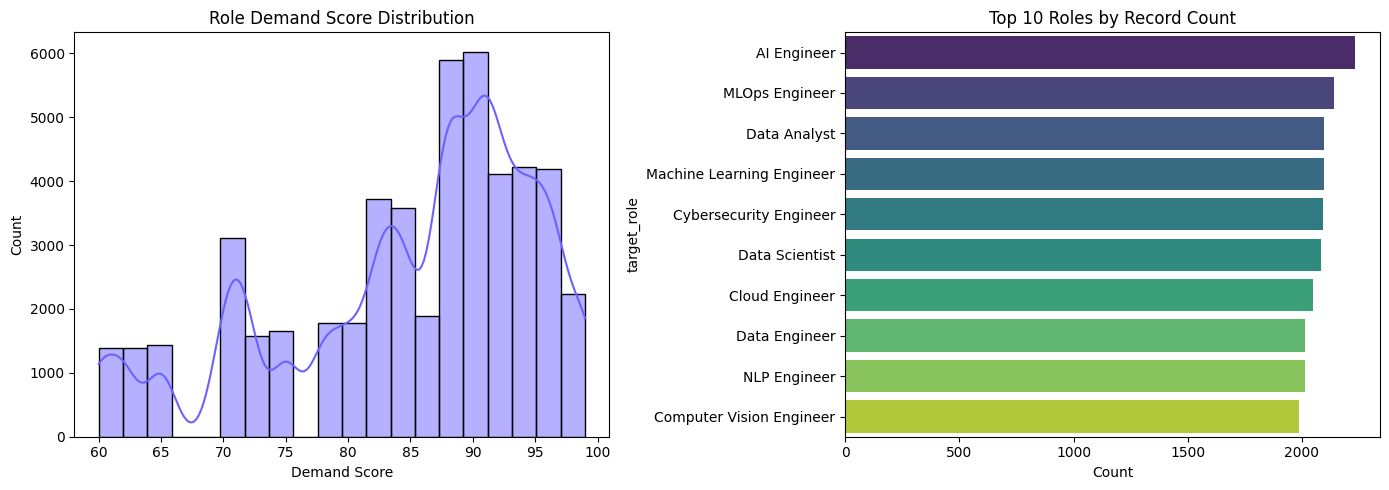

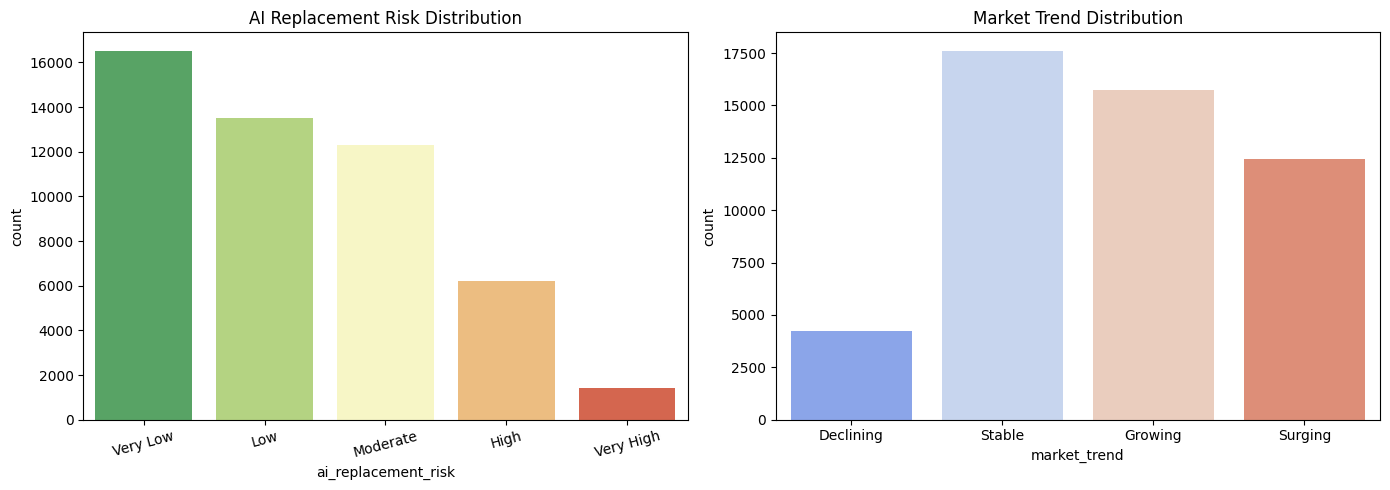


=== Salary Stats ===
count     50000.000000
mean     136341.885000
std       22128.902473
min       95000.000000
25%      122750.000000
50%      140000.000000
75%      153750.000000
max      170750.000000
Name: avg_salary_usd, dtype: float64


In [20]:
# Basic info
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Role Distribution ===")
print(df['target_role'].value_counts())

# Plot 1: Role demand score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['role_demand_score'], bins=20, kde=True, ax=axes[0], color='#6c63ff')
axes[0].set_title('Role Demand Score Distribution')
axes[0].set_xlabel('Demand Score')

# Plot 2: Top 10 roles by count
top_roles = df['target_role'].value_counts().head(10)
sns.barplot(x=top_roles.values, y=top_roles.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Roles by Record Count')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.show()

# Plot 3: AI replacement risk distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
risk_order = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
sns.countplot(x='ai_replacement_risk', data=df, order=risk_order, ax=axes[0], palette='RdYlGn_r')
axes[0].set_title('AI Replacement Risk Distribution')
axes[0].tick_params(axis='x', rotation=15)

# Plot 4: Market trend distribution
trend_order = ['Declining', 'Stable', 'Growing', 'Surging']
sns.countplot(x='market_trend', data=df, order=trend_order, ax=axes[1], palette='coolwarm')
axes[1].set_title('Market Trend Distribution')
plt.tight_layout()
plt.show()

print("\n=== Salary Stats ===")
print(df['avg_salary_usd'].describe())

In [21]:
# ── Work on a COPY so the original df stays intact for lookups ──
data = df.copy()

# ── 1. Parse user_skills correctly: "Python:Advanced|SQL:Beginner" → ["Python","SQL"] ──
def parse_skill_names(skill_str):
    """Extract only the skill name, strip the :Level part."""
    if pd.isna(skill_str) or skill_str == '':
        return []
    return [s.split(':')[0].strip() for s in skill_str.split('|') if s.strip()]

data['user_skills_list'] = data['user_skills'].apply(parse_skill_names)
data['num_user_skills'] = data['user_skills_list'].apply(len)

# ── 2. Correct ordinal mappings (match exactly what's in the dataset) ──
# ai_replacement_risk has 5 values: Very Low, Low, Moderate, High, Very High
risk_map = {'Very Low': 1, 'Low': 2, 'Moderate': 3, 'High': 4, 'Very High': 5}
data['ai_risk_encoded'] = data['ai_replacement_risk'].map(risk_map)

# market_trend: Declining, Stable, Growing, Surging (NOT "Very High")
trend_map = {'Declining': 0, 'Stable': 1, 'Growing': 2, 'Surging': 3}
data['market_trend_encoded'] = data['market_trend'].map(trend_map)

# role_future_demand
future_map = {'Low': 1, 'Moderate': 2, 'High': 3, 'Very High': 4, 'Extremely High': 5}
data['future_demand_encoded'] = data['role_future_demand'].map(future_map)

# ── 3. role_growth_pct is already numeric — DO NOT remap ──
# Verify it's numeric
print("role_growth_pct dtype:", data['role_growth_pct'].dtype)
print("role_growth_pct sample values:", data['role_growth_pct'].unique()[:8])

# ── 4. Encode categorical columns — keep originals, create _enc versions ──
le_role    = LabelEncoder()
le_domain  = LabelEncoder()
le_edu     = LabelEncoder()
le_utype   = LabelEncoder()
le_country = LabelEncoder()

data['role_enc']    = le_role.fit_transform(data['target_role'])
data['domain_enc']  = le_domain.fit_transform(data['role_domain'])
data['edu_enc']     = le_edu.fit_transform(data['education_level'])
data['utype_enc']   = le_utype.fit_transform(data['user_type'])
data['country_enc'] = le_country.fit_transform(data['country'])

# Save encoders for the backend
os.makedirs('../backend/models', exist_ok=True)
joblib.dump(le_role,    '../backend/models/le_role.pkl')
joblib.dump(le_domain,  '../backend/models/le_domain.pkl')
joblib.dump(le_edu,     '../backend/models/le_edu.pkl')

# ── 5. MultiLabelBinarizer on user skills ──
mlb_user = MultiLabelBinarizer()
user_skills_matrix = mlb_user.fit_transform(data['user_skills_list'])
user_skills_df = pd.DataFrame(user_skills_matrix, columns=mlb_user.classes_)

print("\nUser skills binarized shape:", user_skills_df.shape)
print("Sample skill columns:", list(mlb_user.classes_)[:10])

# ── 6. MultiLabelBinarizer on role core skills (for skill classification model) ──
def parse_pipe_list(s):
    if pd.isna(s): return []
    return [x.strip() for x in s.split('|') if x.strip()]

data['core_skills_list'] = data['role_core_skills'].apply(parse_pipe_list)
mlb_role = MultiLabelBinarizer()
role_skills_matrix = mlb_role.fit_transform(data['core_skills_list'])
role_skills_df = pd.DataFrame(role_skills_matrix, columns=mlb_role.classes_)

print("Role skills binarized shape:", role_skills_df.shape)
print("Sample role skill columns:", list(mlb_role.classes_)[:10])

joblib.dump(mlb_user, '../backend/models/mlb_skills.pkl')
joblib.dump(mlb_role, '../backend/models/mlb_role_skills.pkl')

# ── 7. Final feature verification ──
print("\n✅ Preprocessing complete. No NaNs in encoded columns:")
check_cols = ['ai_risk_encoded','market_trend_encoded','future_demand_encoded','role_enc','domain_enc']
print(data[check_cols].isnull().sum())

role_growth_pct dtype: int64
role_growth_pct sample values: [-5  6 30 85 23 40 28 55]

User skills binarized shape: (50000, 192)
Sample skill columns: ['A/B Testing', 'API Integration', 'API Testing', 'AWS', 'AWS RDS', 'Accessibility', 'Active Directory', 'Adobe XD', 'Agile', 'Airflow']
Role skills binarized shape: (50000, 89)
Sample role skill columns: ['API Testing', 'AWS', 'Active Directory', 'Agile', 'Airflow', 'Apache Spark', 'Azure', 'BERT', 'Backup & Recovery', 'Bash']

✅ Preprocessing complete. No NaNs in encoded columns:
ai_risk_encoded          0
market_trend_encoded     0
future_demand_encoded    0
role_enc                 0
domain_enc               0
dtype: int64


Feature matrix shape: (50000, 6)
Target range: 60 – 99
Feature dtypes:
 role_growth_pct          int64
ai_risk_encoded          int64
market_trend_encoded     int64
future_demand_encoded    int64
is_emerging_role         int64
is_at_risk_role          int64
dtype: object

📊 Model 1 — Demand Prediction Results:
   RMSE : 0.000  (lower is better; max score is 100)
   R²   : 1.0000  (1.0 = perfect)

Feature Importances:
role_growth_pct          0.721712
future_demand_encoded    0.199857
ai_risk_encoded          0.026628
is_emerging_role         0.019200
market_trend_encoded     0.016461
is_at_risk_role          0.016142
dtype: float64


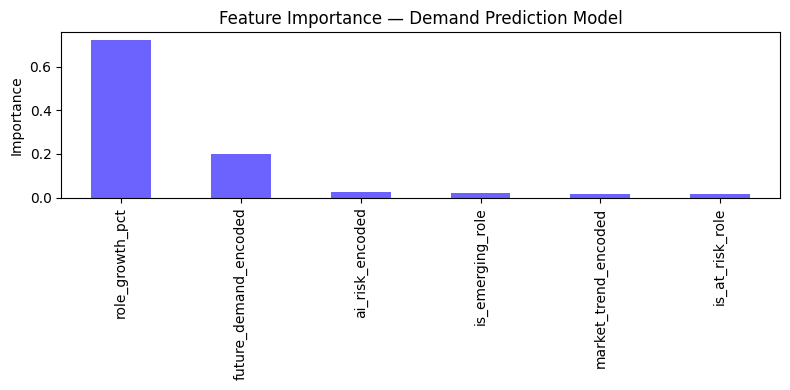


Top 10 Roles by Predicted Demand Score:
              target_role  predicted_demand
              AI Engineer              99.0
Machine Learning Engineer              97.0
   Cybersecurity Engineer              96.0
           Data Scientist              95.0
           MLOps Engineer              94.0
            Data Engineer              93.0
             Data Analyst              92.0
           Cloud Engineer              91.0
             NLP Engineer              91.0
          DevOps Engineer              90.0

✅ Model 1 saved.


In [22]:
# ────────────────────────────────────────────────────────────────────
# GOAL: Predict role_demand_score (0–100) from market features
# This powers the "Market Trends" page — predicting how in-demand
# a role is based on its growth, AI risk, and market direction
# ────────────────────────────────────────────────────────────────────

# Features: market-level signals (NOT scaled — tree models don't need it)
X_demand = data[[
    'role_growth_pct',        # already numeric: -5, 6, 30, 163...
    'ai_risk_encoded',        # 1–5 ordinal
    'market_trend_encoded',   # 0–3 ordinal
    'future_demand_encoded',  # 1–5 ordinal
    'is_emerging_role',       # 0/1 boolean
    'is_at_risk_role',        # 0/1 boolean
]].copy()

# Convert booleans to int
X_demand['is_emerging_role'] = X_demand['is_emerging_role'].astype(int)
X_demand['is_at_risk_role']  = X_demand['is_at_risk_role'].astype(int)

# Target: actual demand score (0–100), already numeric
y_demand = data['role_demand_score']

print("Feature matrix shape:", X_demand.shape)
print("Target range:", y_demand.min(), "–", y_demand.max())
print("Feature dtypes:\n", X_demand.dtypes)

# Train / test split
X_tr, X_te, y_tr, y_te = train_test_split(X_demand, y_demand, test_size=0.2, random_state=42)

# Train model
model_demand = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
model_demand.fit(X_tr, y_tr)

# Evaluate
y_pred_demand = model_demand.predict(X_te)
mse  = mean_squared_error(y_te, y_pred_demand)
rmse = np.sqrt(mse)
r2   = model_demand.score(X_te, y_te)
print(f"\n📊 Model 1 — Demand Prediction Results:")
print(f"   RMSE : {rmse:.3f}  (lower is better; max score is 100)")
print(f"   R²   : {r2:.4f}  (1.0 = perfect)")

# Feature importance
importance = pd.Series(model_demand.feature_importances_, index=X_demand.columns).sort_values(ascending=False)
print("\nFeature Importances:")
print(importance)

plt.figure(figsize=(8, 4))
importance.plot(kind='bar', color='#6c63ff')
plt.title('Feature Importance — Demand Prediction Model')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Show top 10 roles by predicted demand
data['predicted_demand'] = model_demand.predict(X_demand)
top_predicted = (
    data.groupby('target_role')['predicted_demand']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)
print("\nTop 10 Roles by Predicted Demand Score:")
print(top_predicted.to_string(index=False))

# Save model
joblib.dump(model_demand, '../backend/models/demand_prediction_model.pkl')
print("\n✅ Model 1 saved.")

In [23]:
# ────────────────────────────────────────────────────────────────────
# GOAL: Given a user's skills + experience + education,
#       recommend the most suitable job role (classification)
# ────────────────────────────────────────────────────────────────────

# Build feature matrix: base features + user skill binarizer
base_features = pd.DataFrame({
    'years_of_experience': data['years_of_experience'].values,
    'num_user_skills':     data['num_user_skills'].values,
    'skill_gap_count':     data['skill_gap_count'].values,
    'readiness_score':     data['readiness_score'].values,
    'edu_enc':             data['edu_enc'].values,
    'role_demand_score':   data['role_demand_score'].values,
    'role_growth_pct':     data['role_growth_pct'].values,
})

# Combine base + skill binary flags
X_rec = pd.concat([base_features.reset_index(drop=True),
                   user_skills_df.reset_index(drop=True)], axis=1)

# Target: which role does this profile belong to
y_rec = data['role_enc'].values

print("Feature matrix shape:", X_rec.shape)
print("Number of unique roles:", len(np.unique(y_rec)))

# Train / test split
X_tr, X_te, y_tr, y_te = train_test_split(X_rec, y_rec, test_size=0.2, random_state=42, stratify=y_rec)

# Train model
model_rec = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
model_rec.fit(X_tr, y_tr)

# Evaluate
y_pred_rec = model_rec.predict(X_te)
acc = accuracy_score(y_te, y_pred_rec)
print(f"\n📊 Model 2 — Role Recommendation Results:")
print(f"   Accuracy: {acc:.4f}  ({acc*100:.1f}%)")

# Demo: predict for a sample user
sample_user_skills = ['Python', 'SQL', 'Machine Learning']
sample_skills_vec  = mlb_user.transform([sample_user_skills])
sample_base = pd.DataFrame([[2.0, 3, 4, 55, 2, 90, 20]],
                            columns=base_features.columns)
sample_X = pd.concat([sample_base, pd.DataFrame(sample_skills_vec, columns=mlb_user.classes_)], axis=1)

# Align columns (in case any are missing)
for col in X_rec.columns:
    if col not in sample_X.columns:
        sample_X[col] = 0
sample_X = sample_X[X_rec.columns]

# Get top 3 predictions with probabilities
probs     = model_rec.predict_proba(sample_X)[0]
top3_idx  = np.argsort(probs)[::-1][:3]
top3_roles = le_role.inverse_transform(top3_idx)
top3_probs = probs[top3_idx]

print(f"\nSample user — skills: {sample_user_skills}, 2 yrs experience")
print("Top 3 recommended roles:")
for role, prob in zip(top3_roles, top3_probs):
    print(f"  → {role}: {prob*100:.1f}% match")

# Save model and feature column order
joblib.dump(model_rec,         '../backend/models/recommendation_model.pkl')
joblib.dump(list(X_rec.columns), '../backend/models/rec_feature_columns.pkl')
print("\n✅ Model 2 saved.")

Feature matrix shape: (50000, 199)
Number of unique roles: 27

📊 Model 2 — Role Recommendation Results:
   Accuracy: 0.9970  (99.7%)

Sample user — skills: ['Python', 'SQL', 'Machine Learning'], 2 yrs experience
Top 3 recommended roles:
  → DevOps Engineer: 11.3% match
  → Backend Developer: 6.8% match
  → Full Stack Developer: 6.4% match

✅ Model 2 saved.


In [24]:
# ────────────────────────────────────────────────────────────────────
# GOAL: Given a target role's market attributes, predict which
#       skills are required (multi-label classification)
# This drives the "Missing Skills" section of the app
# ────────────────────────────────────────────────────────────────────

# Features: role-level signals
X_skills = data[[
    'role_demand_score',
    'role_growth_pct',
    'ai_risk_encoded',
    'market_trend_encoded',
    'future_demand_encoded',
    'domain_enc',
]].copy()

# Target: binary matrix of which core skills a role requires
# Pick top 40 most common skills for efficiency
skill_freq   = role_skills_df.sum().sort_values(ascending=False)
top_40_skills = skill_freq.head(40).index.tolist()
Y_skills     = role_skills_df[top_40_skills]

print("Feature matrix shape:", X_skills.shape)
print("Target (skills) shape:", Y_skills.shape)
print("Top 10 most required skills:", top_40_skills[:10])

# Train / test split
X_tr, X_te, Y_tr, Y_te = train_test_split(X_skills, Y_skills, test_size=0.2, random_state=42)

# OneVsRest classifier — one binary classifier per skill
clf_skills = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0))
clf_skills.fit(X_tr, Y_tr)

# Evaluate
Y_pred    = clf_skills.predict(X_te)
f1_macro  = f1_score(Y_te, Y_pred, average='macro',  zero_division=0)
f1_micro  = f1_score(Y_te, Y_pred, average='micro',  zero_division=0)
f1_sample = f1_score(Y_te, Y_pred, average='samples', zero_division=0)

print(f"\n📊 Model 3 — Skill Classification Results:")
print(f"   F1 Macro  : {f1_macro:.4f}")
print(f"   F1 Micro  : {f1_micro:.4f}")
print(f"   F1 Samples: {f1_sample:.4f}  ← most meaningful for multi-label")

# Demo: predict required skills for a role
def predict_skills_for_role(role_name):
    row = data[data['target_role'] == role_name].iloc[[0]]
    role_features = row[X_skills.columns]
    predicted = clf_skills.predict(role_features)[0]
    return [skill for skill, val in zip(top_40_skills, predicted) if val == 1]

# Demo: skill gap for a specific user
demo_role        = 'Data Scientist'
demo_user_skills = ['Python', 'SQL', 'Excel']

predicted_req    = predict_skills_for_role(demo_role)
have_skills      = [s for s in predicted_req if s in demo_user_skills]
missing_skills   = [s for s in predicted_req if s not in demo_user_skills]

print(f"\nRole: {demo_role}")
print(f"Predicted required skills : {predicted_req}")
print(f"User has                  : {have_skills}")
print(f"User needs to learn       : {missing_skills}")

# Save
joblib.dump(clf_skills,    '../backend/models/skill_gap_model.pkl')
joblib.dump(top_40_skills, '../backend/models/top_skill_labels.pkl')
print("\n✅ Model 3 saved.")

Feature matrix shape: (50000, 6)
Target (skills) shape: (50000, 40)
Top 10 most required skills: ['Python', 'SQL', 'AWS', 'Linux', 'TensorFlow', 'Machine Learning', 'PyTorch', 'Git', 'JavaScript', 'Deep Learning']

📊 Model 3 — Skill Classification Results:
   F1 Macro  : 0.9069
   F1 Micro  : 0.9050
   F1 Samples: 0.8604  ← most meaningful for multi-label

Role: Data Scientist
Predicted required skills : ['Python', 'SQL', 'TensorFlow', 'Machine Learning', 'PyTorch', 'Statistics']
User has                  : ['Python', 'SQL']
User needs to learn       : ['TensorFlow', 'Machine Learning', 'PyTorch', 'Statistics']

✅ Model 3 saved.


In [25]:
# ────────────────────────────────────────────────────────────────────
# Full end-to-end test: simulate what the website will do
# ────────────────────────────────────────────────────────────────────

def get_missing_skills_for_role(user_skills_list, role_name):
    """Compare user skills against the actual core+secondary skills of a role."""
    matches = df[df['target_role'] == role_name]
    if matches.empty:
        return []
    row = matches.iloc[0]
    core      = parse_pipe_list(row['role_core_skills'])
    secondary = parse_pipe_list(row['role_secondary_skills'])
    all_needed = list(dict.fromkeys(core + secondary))  # preserve order, deduplicate
    missing   = [s for s in all_needed if s not in user_skills_list]
    return missing

def full_recommendation_pipeline(user_skills_input, years_exp, education, interest_domain=''):
    """
    Input : user's skills (list of strings), experience, education
    Output: top roles + readiness + missing skills + roadmap
    """
    LEARNING_RESOURCES = {
        'Python': 'https://realpython.com/', 'SQL': 'https://sqltutorial.org/',
        'Machine Learning': 'https://coursera.org/learn/machine-learning',
        'AWS': 'https://aws.amazon.com/training/', 'Docker': 'https://docs.docker.com/',
        'TensorFlow': 'https://tensorflow.org/tutorials', 'PyTorch': 'https://pytorch.org/tutorials/',
        'Tableau': 'https://tableau.com/learn/training', 'Power BI': 'https://learn.microsoft.com/power-bi/',
        'Deep Learning': 'https://fast.ai/', 'NLP': 'https://huggingface.co/learn/nlp-course/',
    }

    # Encode education
    try:
        edu_enc_val = le_edu.transform([education])[0]
    except Exception:
        edu_enc_val = 2  # default Bachelor's

    # Build skill vector
    skill_vec = mlb_user.transform([user_skills_input])

    # Estimate feature values
    n_skills    = len(user_skills_input)
    gap_est     = max(0, 5 - n_skills)   # rough estimate
    readiness   = max(10, min(100, int(n_skills * 8 + years_exp * 4)))

    base = pd.DataFrame([[years_exp, n_skills, gap_est, readiness, edu_enc_val, 85, 20]],
                         columns=base_features.columns)
    X_input = pd.concat([base, pd.DataFrame(skill_vec, columns=mlb_user.classes_)], axis=1)
    for col in X_rec.columns:
        if col not in X_input.columns:
            X_input[col] = 0
    X_input = X_input[X_rec.columns]

    # Model 2: Top 3 role recommendations
    probs    = model_rec.predict_proba(X_input)[0]
    top3_idx = np.argsort(probs)[::-1][:3]
    top_roles = le_role.inverse_transform(top3_idx)
    top_probs = probs[top3_idx]

    print("=" * 55)
    print(f"👤 User: {years_exp} yrs exp | {education} | {n_skills} skills")
    print(f"   Skills: {user_skills_input}")
    print("=" * 55)

    for i, (role, prob) in enumerate(zip(top_roles, top_probs)):
        missing = get_missing_skills_for_role(user_skills_input, role)
        role_row = df[df['target_role'] == role].iloc[0]

        print(f"\n🏆 Rank {i+1}: {role}  ({prob*100:.1f}% match)")
        print(f"   Domain      : {role_row['role_domain']}")
        print(f"   Demand Score: {role_row['role_demand_score']}")
        print(f"   Avg Salary  : ${role_row['avg_salary_usd']:,}")
        print(f"   AI Risk     : {role_row['ai_replacement_risk']}")
        print(f"   Market Trend: {role_row['market_trend']}")
        print(f"   Missing Skills ({len(missing)}): {missing[:5]}")

        if missing:
            print(f"   📚 Roadmap:")
            for step, skill in enumerate(missing[:4], 1):
                link = LEARNING_RESOURCES.get(skill, 'https://coursera.org/')
                print(f"      Step {step}: Learn {skill} → {link}")

    print(f"\n✅ Readiness Score: {readiness}/100")
    return top_roles, top_probs

# ── Run the full pipeline test ──
print("\n🧪 TEST 1: Fresher with basic skills")
full_recommendation_pipeline(
    user_skills_input=['Python', 'SQL'],
    years_exp=0.5,
    education="Bachelor's"
)

print("\n\n🧪 TEST 2: Experienced ML engineer")
full_recommendation_pipeline(
    user_skills_input=['Python', 'Machine Learning', 'TensorFlow', 'PyTorch', 'SQL', 'AWS', 'Docker'],
    years_exp=5.0,
    education="Master's",
    interest_domain='AI & ML'
)

print("\n\n🧪 TEST 3: Career changer from business background")
full_recommendation_pipeline(
    user_skills_input=['Excel', 'SQL', 'Tableau', 'Communication', 'Stakeholder Management'],
    years_exp=3.0,
    education="Bachelor's",
    interest_domain='Data & Analytics'
)


🧪 TEST 1: Fresher with basic skills
👤 User: 0.5 yrs exp | Bachelor's | 2 skills
   Skills: ['Python', 'SQL']

🏆 Rank 1: Backend Developer  (8.2% match)
   Domain      : Software Development
   Demand Score: 84
   Avg Salary  : $130,000
   AI Risk     : Moderate
   Market Trend: Stable
   Missing Skills (11): ['Java', 'Node.js', 'REST APIs', 'Git', 'Django']
   📚 Roadmap:
      Step 1: Learn Java → https://coursera.org/
      Step 2: Learn Node.js → https://coursera.org/
      Step 3: Learn REST APIs → https://coursera.org/
      Step 4: Learn Git → https://coursera.org/

🏆 Rank 2: Full Stack Developer  (7.7% match)
   Domain      : Software Development
   Demand Score: 85
   Avg Salary  : $125,000
   AI Risk     : Moderate
   Market Trend: Stable
   Missing Skills (10): ['JavaScript', 'React', 'Node.js', 'Git', 'TypeScript']
   📚 Roadmap:
      Step 1: Learn JavaScript → https://coursera.org/
      Step 2: Learn React → https://coursera.org/
      Step 3: Learn Node.js → https://cours

(array(['Backend Developer', 'Full Stack Developer', 'Data Analyst'],
       dtype=object),
 array([0.07802019, 0.07270566, 0.07209002]))

In [26]:
# Final check — make sure all model files exist
model_files = [
    '../backend/models/demand_prediction_model.pkl',
    '../backend/models/recommendation_model.pkl',
    '../backend/models/skill_gap_model.pkl',
    '../backend/models/le_role.pkl',
    '../backend/models/le_domain.pkl',
    '../backend/models/le_edu.pkl',
    '../backend/models/mlb_skills.pkl',
    '../backend/models/mlb_role_skills.pkl',
    '../backend/models/rec_feature_columns.pkl',
    '../backend/models/top_skill_labels.pkl',
]

print("📁 Model files status:")
all_ok = True
for f in model_files:
    exists = os.path.exists(f)
    status = "✅" if exists else "❌ MISSING"
    print(f"  {status}  {f}")
    if not exists:
        all_ok = False

if all_ok:
    print("\n🎉 All models saved successfully! Your backend is ready.")
    print("   Next step: run `uvicorn main:app --reload` in the backend/ folder")
else:
    print("\n⚠️ Some models are missing. Re-run the cells above.")

📁 Model files status:
  ✅  ../backend/models/demand_prediction_model.pkl
  ✅  ../backend/models/recommendation_model.pkl
  ✅  ../backend/models/skill_gap_model.pkl
  ✅  ../backend/models/le_role.pkl
  ✅  ../backend/models/le_domain.pkl
  ✅  ../backend/models/le_edu.pkl
  ✅  ../backend/models/mlb_skills.pkl
  ✅  ../backend/models/mlb_role_skills.pkl
  ✅  ../backend/models/rec_feature_columns.pkl
  ✅  ../backend/models/top_skill_labels.pkl

🎉 All models saved successfully! Your backend is ready.
   Next step: run `uvicorn main:app --reload` in the backend/ folder


In [1]:
import json, os
import pandas as pd

df = pd.read_csv('../data/triintel_dataset.csv')

def parse_pipe_list(s):
    if pd.isna(s): return []
    return [x.strip() for x in str(s).split('|') if x.strip()]

# ── role_skills_map.json ──────────────────────────────────────────
role_skills_map = {}
for role in df['target_role'].unique():
    row = df[df['target_role'] == role].iloc[0]
    role_skills_map[role] = {
        'core':      parse_pipe_list(row['role_core_skills']),
        'secondary': parse_pipe_list(row['role_secondary_skills'])
    }

# ── role_info_map.json ────────────────────────────────────────────
role_info_map = {}
for role in df['target_role'].unique():
    row = df[df['target_role'] == role].iloc[0]
    role_info_map[role] = {
        'demand_score':        int(row['role_demand_score']),
        'future_demand':       row['role_future_demand'],
        'ai_replacement_risk': row['ai_replacement_risk'],
        'growth_pct':          int(row['role_growth_pct']),
        'market_trend':        row['market_trend'],
        'avg_salary_usd':      int(row['avg_salary_usd']),
        'is_emerging':         bool(row['is_emerging_role']),
        'is_at_risk':          bool(row['is_at_risk_role']),
        'domain':              row['role_domain'],
        'education_required':  row['education_typically_required'],
    }

# ── trending_roles.json ───────────────────────────────────────────
trending = (
    df.groupby('target_role')['role_demand_score']
    .first()
    .sort_values(ascending=False)
    .head(10)
)
trending_roles = [
    {
        'role':         role,
        'demand_score': int(score),
        'domain':       role_info_map[role]['domain'],
        'growth_pct':   role_info_map[role]['growth_pct'],
        'ai_risk':      role_info_map[role]['ai_replacement_risk'],
        'trend':        role_info_map[role]['market_trend'],
        'avg_salary':   role_info_map[role]['avg_salary_usd'],
    }
    for role, score in trending.items()
]

# ── top_skills.json ───────────────────────────────────────────────
from collections import Counter

def parse_skill_names(s):
    if pd.isna(s): return []
    return [x.split(':')[0].strip() for x in s.split('|') if x.strip()]

skill_counter = Counter(
    sk for skills in df['user_skills'].apply(parse_skill_names) for sk in skills
)
top_skills = [{'skill': s, 'count': c} for s, c in skill_counter.most_common(20)]

# ── all_roles.json ────────────────────────────────────────────────
all_roles = sorted(df['target_role'].unique().tolist())

# ── all_skills_list.json ──────────────────────────────────────────
all_skills_list = sorted(set(
    sk for skills in df['user_skills'].apply(parse_skill_names) for sk in skills
))

# ── Save all JSON files to backend/models/ ────────────────────────
out = '../backend/models/'
os.makedirs(out, exist_ok=True)

with open(out + 'role_skills_map.json',  'w') as f: json.dump(role_skills_map,  f)
with open(out + 'role_info_map.json',    'w') as f: json.dump(role_info_map,    f)
with open(out + 'trending_roles.json',   'w') as f: json.dump(trending_roles,   f)
with open(out + 'top_skills.json',       'w') as f: json.dump(top_skills,       f)
with open(out + 'all_roles.json',        'w') as f: json.dump(all_roles,        f)
with open(out + 'all_skills_list.json',  'w') as f: json.dump(all_skills_list,  f)

print("✅ All JSON files saved to backend/models/")
print("Files:", os.listdir(out))

✅ All JSON files saved to backend/models/
Files: ['all_roles.json', 'all_skills_list.json', 'demand_prediction_model.pkl', 'le_domain.pkl', 'le_edu.pkl', 'le_role.pkl', 'mlb_role_skills.pkl', 'mlb_skills.pkl', 'recommendation_model.pkl', 'rec_feature_columns.pkl', 'role_info_map.json', 'role_skills_map.json', 'skill_gap_model.pkl', 'top_skills.json', 'top_skill_labels.pkl', 'trending_roles.json']
